
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.     

2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv
  desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$ 
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$

  



### Fisica computacional I 
### Estudiante : Laura Velasquez Bolivar 
### Laboratorio 2 


### Punto 1 


In [3]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/mpg.csv'

df_mpg = pd.read_csv(url)

df_mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [5]:
datos = df_mpg[['mpg', 'horsepower']].dropna()

datos.head()

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0


In [6]:
len(datos)


392

In [7]:
datos.describe()

,mpg,horsepower
count,392.000000,392.000000
mean,23.445918,104.469388
std,7.805007,38.491160
min,9.000000,46.000000
25%,17.000000,75.000000
50%,22.750000,93.500000
75%,29.000000,126.000000
max,46.600000,230.000000


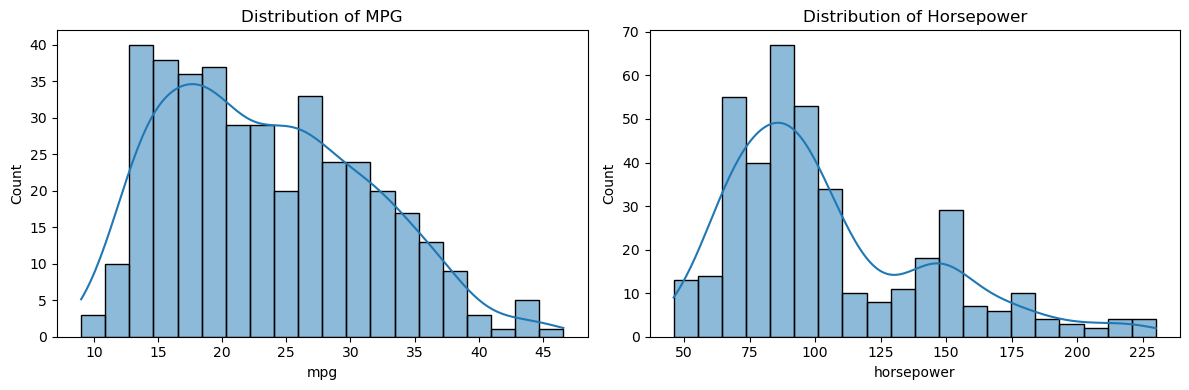

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=datos,
    x='mpg',
    bins=20,
    kde=True,
    ax=ax[0]
)

sns.histplot(
    data=datos,
    x='horsepower',
    bins=20,
    kde=True,
    ax=ax[1]
)

ax[0].set_title('Distribution of MPG')
ax[1].set_title('Distribution of Horsepower')

plt.tight_layout()
plt.show()

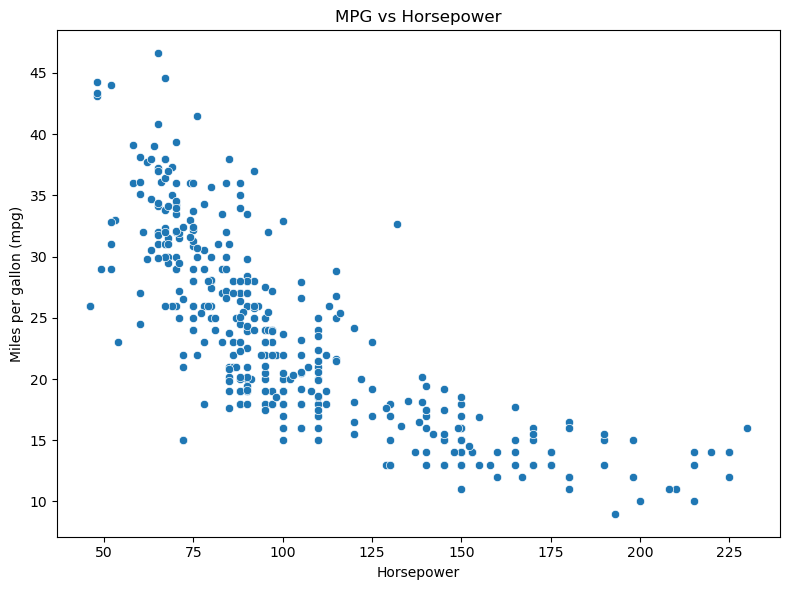

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=datos,
    x='horsepower',
    y='mpg',
    ax=ax
)

ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon (mpg)')
ax.set_title('MPG vs Horsepower')

plt.tight_layout()
plt.show()

In [10]:
correlation = datos['horsepower'].corr(datos['mpg'])

correlation

-0.7784267838977759

In [11]:
fit = np.polyfit(
    datos['horsepower'],
    datos['mpg'],
    1
)

fit

array([-0.15784473, 39.93586102])

In [12]:
slope = fit[0]
intercept = fit[1]

print('Slope =', slope)
print('Intercept =', intercept)

Slope = -0.15784473335365382
Intercept = 39.935861021170496


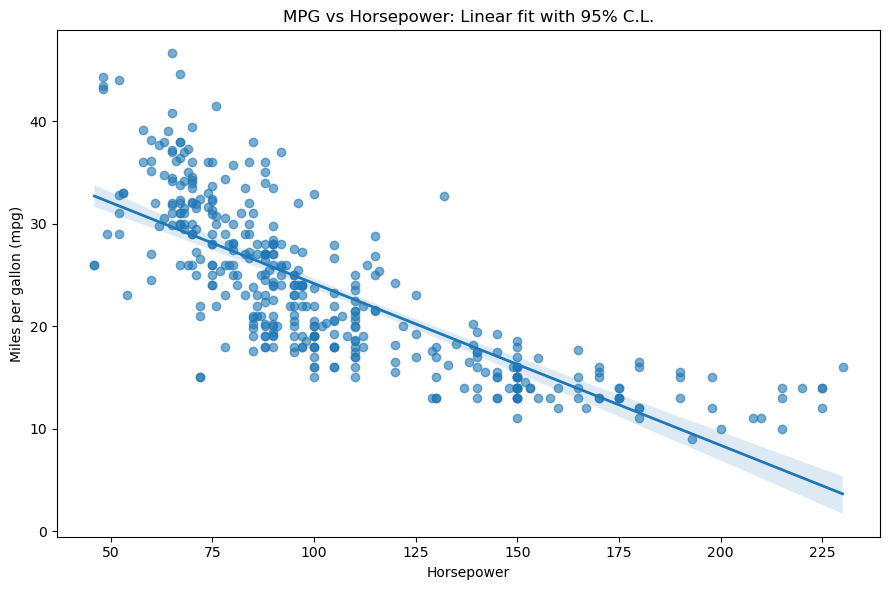

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=datos,
    x='horsepower',
    y='mpg',
    ci=95,
    scatter_kws={'alpha': 0.6},
    line_kws={'linewidth': 2},
    ax=ax
)

ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon (mpg)')
ax.set_title('MPG vs Horsepower: Linear fit with 95% C.L.')

plt.tight_layout()
plt.show()

In [14]:
r2 = correlation**2

print('R² =', r2)


R² = 0.6059482578894346


In [15]:
correlation = datos['horsepower'].corr(datos['mpg'])
r2 = correlation**2

fit = np.polyfit(
    datos['horsepower'],
    datos['mpg'],
    1
)

slope = fit[0]
intercept = fit[1]

print(f'Number of data points = {len(datos)}')
print(f'Pearson correlation = {correlation:.4f}')
print(f'R² = {r2:.4f}')
print(f'Slope = {slope:.4f}')
print(f'Intercept = {intercept:.4f}')
print(f'Fit: mpg = {intercept:.4f} {slope:+.4f} horsepower')

Number of data points = 392
Pearson correlation = -0.7784
R² = 0.6059
Slope = -0.1578
Intercept = 39.9359
Fit: mpg = 39.9359 -0.1578 horsepower


## Conclusiones

La idea de analizar y caracterizar las variables mpg y horsepower por separado es tener una idea de la cantidad de datos que tenemos disponibles y verificar que podamos trabajar correctamente con ambas variables. Esto es importante porque originalmente hay más filas en el conjunto de datos, pero algunas no tienen un valor registrado para horsepowe. Por esta razón, para el análisis se utilizan únicamente los datos en los que tenemos información tanto de mpg como de horsepower.

Hallar las diferentes variables estadísticas nos ayuda a responder varias preguntas sobre los datos, por ejemplo: ¿cuál es aproximadamente el rendimiento promedio de los automóviles?, ¿cuál es aproximadamente la potencia promedio?, ¿qué tan dispersos son los valores de potencia y rendimiento dentro de la muestra?, y ¿desde qué valores mínimos hasta qué valores máximos estamos construyendo nuestro análisis?

Los histogramas nos dan una forma visual de observar cómo están distribuidos los valores de cada variable. En el caso de horsepower, se puede observar que hay una mayor cantidad de automóviles con valores de potencia bajos e intermedios y una menor cantidad de vehículos con valores de potencia muy altos. Para mpg, la mayor parte de los automóviles se encuentra en valores intermedios de rendimiento, aunque también existen vehículos con valores de mpg más altos. Estas gráficas nos permiten identificar en qué zonas se concentra la mayor parte de los datos y si existen valores que se alejan del comportamiento general.

El diagrama de dispersión permite determinar visualmente si existe una relación entre la potencia y la eficiencia de combustible. La nube de puntos muestra una tendencia descendente, lo que sugiere que a medida que aumenta horsepower, el valor de mpg tiende a disminuir. Esto indica que existe una relación negativa entre ambas variables.

El coeficiente de correlación de Pearson obtenido  confirma lo que se observa en el diagrama de dispersión. El signo negativo indica que las dos variables tienden a cambiar en sentidos opuestos: cuando aumenta la potencia, el rendimiento en millas por galón tiende a disminuir.

El ajuste lineal obtenido donde la pendiente es negativa también muestra esta relación. De acuerdo con el modelo, por cada aumento de \(10\,hp\), el valor de mpg disminuye en promedio aproximadamente \(1.58\,mpg\).

El valor de

$$
R^2\approx0.606
$$

nos indica que aproximadamente el 60.6 % de los cambios observados en mpg pueden ser representados por la relación lineal con horsepower. Esto también muestra que horsepower no es la única variable relacionada con el rendimiento del automóvil, ya que existen otras características como el peso, el número de cilindros o el tamaño del motor que también pueden influir.

La gráfica realizada con sns.regplot() permite observar en una misma figura los datos, la línea de ajuste y la región correspondiente al 95 % de confianza. La línea muestra la tendencia general entre horsepower y mpg, mientras que la región sombreada representa la incertidumbre que existe alrededor de ese ajuste.



In [16]:
!wget -O general-scan.csv https://raw.githubusercontent.com/anferivera/SDdiracDM/master/general-scan.csv

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


### Punto 2

In [17]:
from urllib.request import urlretrieve

url = 'https://raw.githubusercontent.com/anferivera/SDdiracDM/master/general-scan.csv'
filename = 'general-scan.csv'

urlretrieve(url, filename)

print('Archivo descargado:', filename)

Archivo descargado: general-scan.csv


In [18]:
import os

print(os.path.exists('general-scan.csv'))
print(os.path.getsize('general-scan.csv'))

True
15037625


In [19]:
filename = 'general-scan.csv'

df = pd.read_csv(filename)

df.head()

,Unnamed: 0,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,...,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.0,0.217236,702.109163,...,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.0,0.019173,329.668504,...,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816
2,2,452.875632,2.469280e+06,2.469280e+06,0.000490,0.000490,0.017861,0.0,0.337367,3843.138599,...,0.000638,0.0,4.833919e-18,1.220000e-26,0.999994,-0.003384,0.003384,0.999994,0.002822,0.000000
3,3,589.443344,9.826674e+07,9.826674e+07,0.042790,0.042790,0.031174,0.0,0.270921,314.258778,...,0.000181,0.0,9.406560e-16,2.740000e-30,0.979480,-0.201541,0.201541,0.979480,0.002838,0.000194
4,4,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.0,0.046671,13048.623894,...,0.000066,0.0,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000


In [20]:
df.shape

(17396, 60)

In [21]:
df.columns

Index(['Unnamed: 0', 'MDF', 'MS12', 'MS22', 'LamS1H', 'LamS2H', 'LamSPH',
       'LamS', 'LamSP', 'vS', 'YRD', 'YRC', 'YRA11', 'YRA12', 'YRA13', 'YRA21',
       'YRA22', 'YRA23', 'YRB11', 'YRB12', 'YRB13', 'YRB21', 'YRB22', 'YRB23',
       'mh1', 'mh2', 'mv3', 'mv2', 'mv1', 'mS1', 'mS2', 'mCha', 'mChi1',
       'mChi2', 'XV11', 'XV12', 'XV21', 'XV22', 'XU11', 'XU12', 'XU21', 'XU22',
       'vevSM', 'Omega', 'PSI', 'PSD', 'NSI', 'NSD', 'T', 'S', 'U', 'mueg',
       'taumug', 'sv', 'ZH11', 'ZH12', 'ZH21', 'ZH22', 'BRh1gg', 'BRh2gg'],
      dtype='object')

In [22]:
df[['vS', 'YRC', 'MDF', 'mChi1', 'Omega']].head()

,vS,YRC,MDF,mChi1,Omega
0,702.109163,0.267003,396.848661,125.748354,0.135
1,329.668504,0.973918,5988.499243,227.030614,0.127
2,3843.138599,0.022039,452.875632,58.708865,0.133
3,314.258778,0.928295,589.443344,206.197269,0.139
4,13048.623894,0.803591,1092.250036,1092.250000,0.119


In [23]:
df[['vS', 'YRC', 'MDF', 'mChi1', 'Omega']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17396 entries, 0 to 17395
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vS      17396 non-null  float64
 1   YRC     17396 non-null  float64
 2   MDF     17396 non-null  float64
 3   mChi1   17396 non-null  float64
 4   Omega   17396 non-null  float64
dtypes: float64(5)
memory usage: 679.7 KB


In [24]:
df['MN'] = df['YRC'] * df['vS'] / np.sqrt(2)


In [25]:
df[['vS', 'YRC', 'MN']].head()

,vS,YRC,MN
0,702.109163,0.267003,132.558085
1,329.668504,0.973918,227.030952
2,3843.138599,0.022039,59.890020
3,314.258778,0.928295,206.280709
4,13048.623894,0.803591,7414.553232


In [30]:
Omega_DM = 0.12

In [31]:
Omega_min = 0.115
Omega_max = 0.125

correctos = df[
    (df['Omega'] > Omega_min) &
    (df['Omega'] < Omega_max)
].copy()

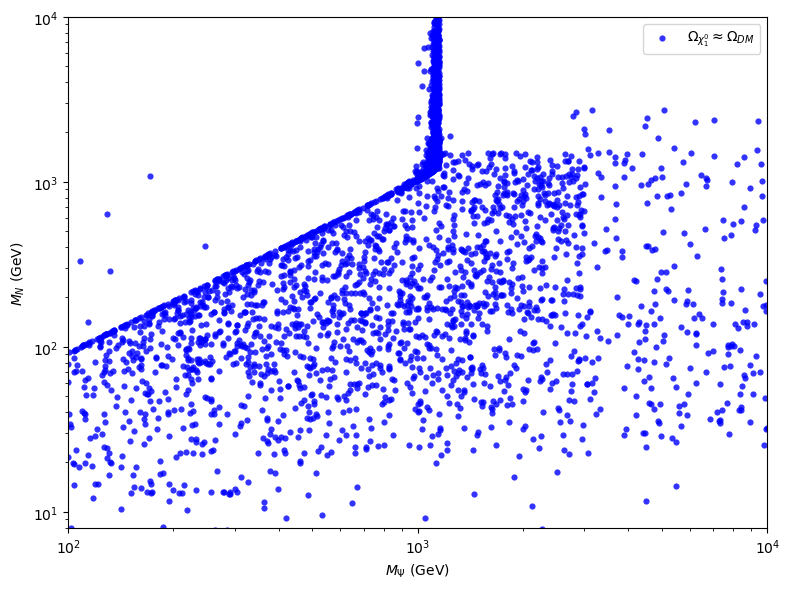

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=correctos,
    x='MDF',
    y='MN',
    color='blue',
    s=20,
    alpha=0.8,
    linewidth=0,
    label=r'$\Omega_{\chi_1^0}\approx\Omega_{DM}$',
    ax=ax
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e2, 1e4)
ax.set_ylim(8, 1e4)

ax.set_xlabel(r'$M_{\Psi}$ (GeV)')
ax.set_ylabel(r'$M_N$ (GeV)')

ax.legend()

plt.tight_layout()
plt.show()

In [33]:
sub = df[df['Omega'] <= Omega_min]
sobre = df[df['Omega'] >= Omega_max]

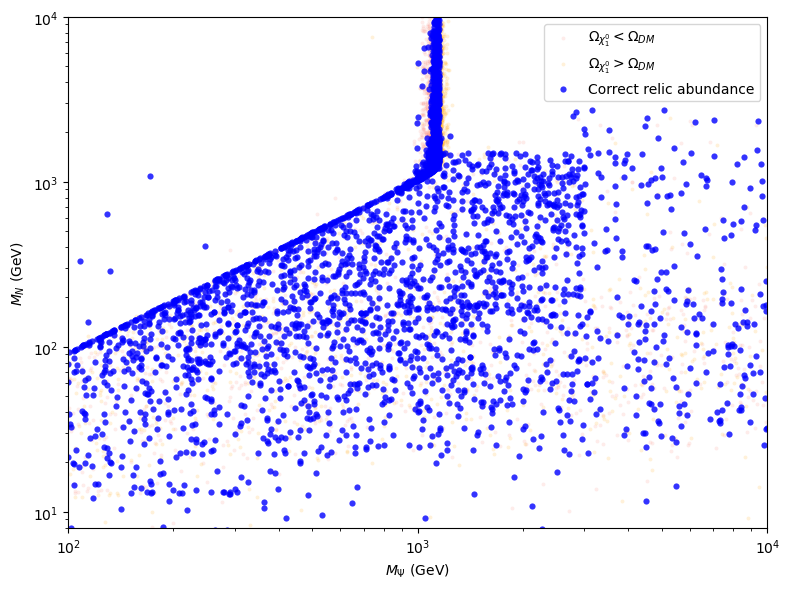

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=sub,
    x='MDF',
    y='MN',
    s=8,
    alpha=0.15,
    color='salmon',
    label=r'$\Omega_{\chi_1^0}<\Omega_{DM}$',
    ax=ax
)

sns.scatterplot(
    data=sobre,
    x='MDF',
    y='MN',
    s=8,
    alpha=0.15,
    color='orange',
    label=r'$\Omega_{\chi_1^0}>\Omega_{DM}$',
    ax=ax
)

sns.scatterplot(
    data=correctos,
    x='MDF',
    y='MN',
    color='blue',
    s=20,
    alpha=0.8,
    linewidth=0,
    label='Correct relic abundance',
    ax=ax
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e2, 1e4)
ax.set_ylim(8, 1e4)

ax.set_xlabel(r'$M_{\Psi}$ (GeV)')
ax.set_ylabel(r'$M_N$ (GeV)')

ax.legend()

plt.tight_layout()
plt.show()

In [36]:
# Filtros físicos básicos

datos = df[
    (df['mh1'] >= 124.5) &
    (df['mh2'] >= 124.5) &
    (np.abs(df['ZH12']) < 0.3)
].copy()

# Parámetros que deben cumplir |parámetro| < 3
parametros = [
    'YRC',
    'LamSP',
    'LamSPH',
    'YRB11',
    'YRB12',
    'YRB13',
    'YRB21',
    'YRB22',
    'YRB23'
]

for parametro in parametros:
    datos = datos[np.abs(datos[parametro]) < 3]

# Selección de abundancia relicta correcta
Omega_min = 0.115
Omega_max = 0.125

correctos = datos[
    (datos['Omega'] > Omega_min) &
    (datos['Omega'] < Omega_max)
].copy()

print('Datos originales:', len(df))
print('Después de filtros físicos:', len(datos))
print('Con abundancia relicta correcta:', len(correctos))

Datos originales: 17396
Después de filtros físicos: 13702
Con abundancia relicta correcta: 10098


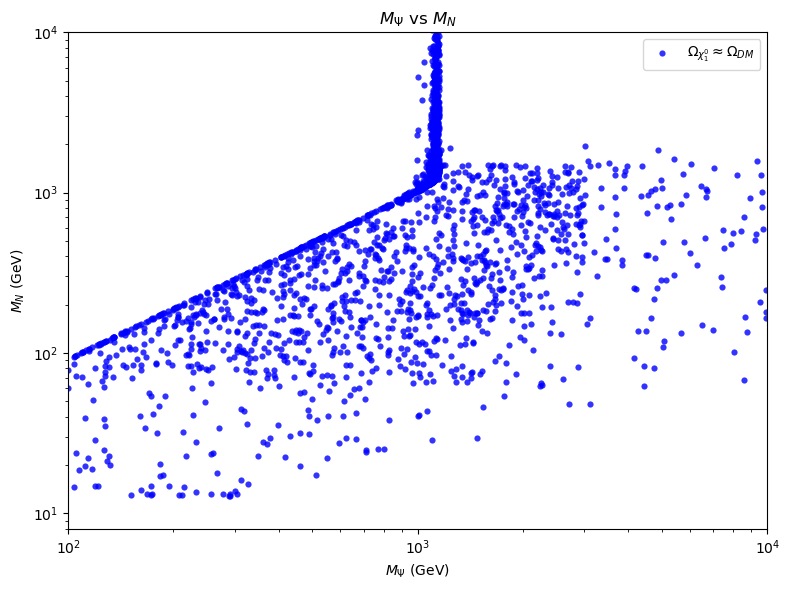

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=correctos,
    x='MDF',
    y='MN',
    color='blue',
    s=20,
    alpha=0.8,
    linewidth=0,
    label=r'$\Omega_{\chi_1^0}\approx\Omega_{DM}$',
    ax=ax
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e2, 1e4)
ax.set_ylim(8, 1e4)

ax.set_xlabel(r'$M_{\Psi}$ (GeV)')
ax.set_ylabel(r'$M_N$ (GeV)')

ax.set_title(r'$M_{\Psi}$ vs $M_N$')

ax.legend()

plt.tight_layout()
plt.show()